# Section 4 — VaR backtesting

*Would the usual volatility estimators have kept a 99% 10-day VaR honest through the recent stress periods, and what do they say today?*

Section 2 showed that the level of measured risk depends on the estimator's lookback and that the short-memory estimators are currently near the bottom of their range. This section tests estimators of that kind on SPY from 2014 to September 2026, with particular attention to four windows: February to June 2020, calendar 2022, February to June 2025, and 2026 to date.

Conventions: 99% confidence and a 10-day horizon. The volatility estimate on day $t$ uses returns up to and including day $t$. $\mathrm{VaR}_t = z\cdot\sigma_t\cdot\sqrt{10}$ with $z = \Phi^{-1}(0.01)$; the forward return is $\ln(S_{t+10}/S_t)$; a breach is a forward return below $\mathrm{VaR}_t$. Zones use Binomial($T$, 0.01) percentiles: green up to the 95th, yellow up to the 99.99th, red beyond. This is a stylized version of the Basel traffic light, which is defined on 250 one-day comparisons.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from quiet_index import config as cfg
from quiet_index import data, pipeline, plots

pd.set_option("display.width", 200)
study_data = data.load_study_data() #cached prices, returns and index weights, cut off at the study end date

from quiet_index import backtest

section_4 = pipeline.run_section_4(study_data)
tables = section_4["tables"]
backtest_data, breach_data = section_4["backtest_data"], section_4["breach_data"]
print(f"backtest: {backtest_data.index[0].date()} to {backtest_data.index[-1].date()}, {len(backtest_data)} days, {len(backtest_data) * 0.01:.0f} breaches expected at 99%")

backtest: 2014-01-02 to 2026-09-16, 3195 days, 32 breaches expected at 99%


## 4.1 Four volatility models

- Rolling 21d: equal-weighted standard deviation of the last 21 daily returns.
- EWMA 0.72: $\sigma^2_t = \lambda\,\sigma^2_{t-1} + (1-\lambda)\,r_t^2$ with a fast decay; half-life about 2 days.
- Calibrated EWMA: the same recursion with $\lambda$ chosen from the data, below.
- GARCH(1,1): $\sigma^2_{t+1} = \omega + \alpha\,r_t^2 + \beta\,\sigma^2_t$, re-estimated every 21 trading days on all data up to that day.

## 4.2 Calibrating $\lambda$

For each $\lambda$ between 0.70 and 0.99, today's EWMA variance is treated as the forecast of tomorrow's squared return, and the forecast is scored over 2014 to 2019. The calibration period ends before the first test window, so all four windows are out of sample for this parameter.

lowest QLIKE at lambda = 0.93, lowest RMSE at lambda = 0.85
RMSE across the whole grid: 0.000155 to 0.000162


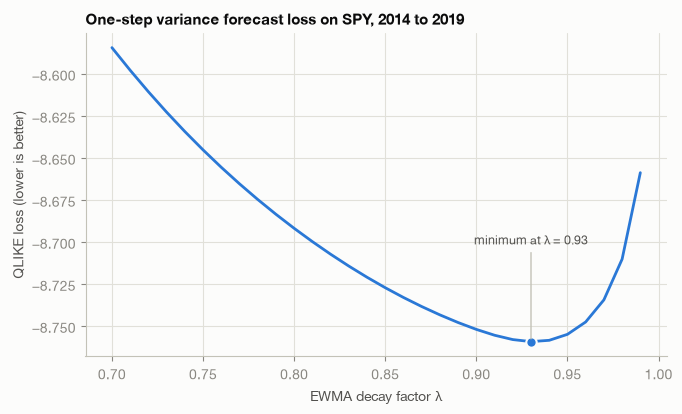

In [2]:
loss_curve = tables["s4_lambda_loss_curve"]
calibrated_lambda = section_4["calibrated_lambda"]
print(f"lowest QLIKE at lambda = {calibrated_lambda}, lowest RMSE at lambda = {backtest.calibrate_lambda(loss_curve, 'rmse')}")
print(f"RMSE across the whole grid: {loss_curve['rmse'].min():.6f} to {loss_curve['rmse'].max():.6f}")

plots.plot_lambda_loss_curve(loss_curve, calibrated_lambda);

The calibrated value is 0.93, one step from the RiskMetrics convention of 0.94, with a half-life of about 10 trading days.

Two loss functions were computed and they do not agree. QLIKE, which scores the ratio of the realized squared return to the forecast, has a clear minimum at 0.93. Root-mean-squared error has its minimum at 0.85, but it is almost flat across the whole grid (0.000155 to 0.000162), because squared-error loss on squared returns is dominated by a handful of extreme days that no decay factor forecasts well. A criterion that can barely tell 0.72 from 0.97 is not a useful basis for choosing between them, so QLIKE is used.

## 4.3 GARCH(1,1)

The model is fitted first on 2013 and then re-estimated every 21 trading days on an expanding window, so a forecast made on any day uses only parameters estimated from data up to that day. Its 10-day VaR uses the model's own 10-day variance, which is the sum of ten daily forecasts that each revert toward the long-run variance at rate $\alpha + \beta$, in place of the $\sqrt{10}$ scaling applied to the other three models.

In [3]:
garch_parameters = tables["s4_garch_parameters"]
latest = garch_parameters.iloc[-1]
print(f"{len(garch_parameters)} re-estimations; latest: alpha {latest['alpha']:.3f}, beta {latest['beta']:.3f}, "
      f"persistence {latest['persistence']:.3f}, half-life {np.log(0.5) / np.log(latest['persistence']):.0f} days")
garch_parameters[["alpha", "beta", "persistence"]].agg(["min", "mean", "max"]).round(3)

153 re-estimations; latest: alpha 0.162, beta 0.797, persistence 0.960, half-life 17 days


,alpha,beta,persistence
min,0.132,0.619,0.768
mean,0.183,0.742,0.924
max,0.214,0.798,0.968


## 4.4 Grades by model and window

In [4]:
grades = tables["s4_backtest_grades"]
grades[["observations", "breaches", "breach_pct", "green_cutoff", "yellow_cutoff", "zone", "kupiec_p", "christoffersen_p"]].round(4)

observations  breaches  breach_pct  green_cutoff  yellow_cutoff    zone  kupiec_p  christoffersen_p
window       model                                                                                                                      
2020 Feb-Jun Rolling 21d                      104        17      0.1635             3              6     Red    0.0000            0.0000
             EWMA 0.72                        104        13      0.1250             3              6     Red    0.0000            0.0000
             EWMA 0.93 (calibrated)           104        17      0.1635             3              6     Red    0.0000            0.0000
             GARCH(1,1)                       104        17      0.1635             3              6     Red    0.0000            0.0000
2022         Rolling 21d                      251         6      0.0239             5             10  Yellow    0.0604            0.0001
             EWMA 0.72                        251        12      0.0478             5             10     Red    0.0000            0.0000
             EWMA 0.93 (calibrated)           251         5      0.0199             5             10   Green    0.1640            0.0000
             GARCH(1,1)                       251        13      0.0518             5             10     Red    0.0000            0.0000
2025 Feb-Jun Rolling 21d                      102        10      0.0980             3              6     Red    0.0000            0.0000
             EWMA 0.72                        102        10      0.0980             3              6     Red    0.0000            0.0004
             EWMA 0.93 (calibrated)           102         8      0.0784             3              6     Red    0.0000            0.0006
             GARCH(1,1)                       102         8      0.0784             3              6     Red    0.0000            0.0116
2026 YTD     Rolling 21d                      177         0      0.0000             4              8   Green    0.0593               NaN
             EWMA 0.72                        177         0      0.0000             4              8   Green    0.0593               NaN
             EWMA 0.93 (calibrated)           177         0      0.0000             4              8   Green    0.0593               NaN
             GARCH(1,1)                       177         0      0.0000             4              8   Green    0.0593               NaN
Full period  Rolling 21d                     3195        96      0.0300            41             55     Red    0.0000            0.0000
             EWMA 0.72                       3195       111      0.0347            41             55     Red    0.0000            0.0000
             EWMA 0.93 (calibrated)          3195        81      0.0254            41             55     Red    0.0000            0.0000
             GARCH(1,1)                      3195        75      0.0235            41             55     Red    0.0000            0.0000

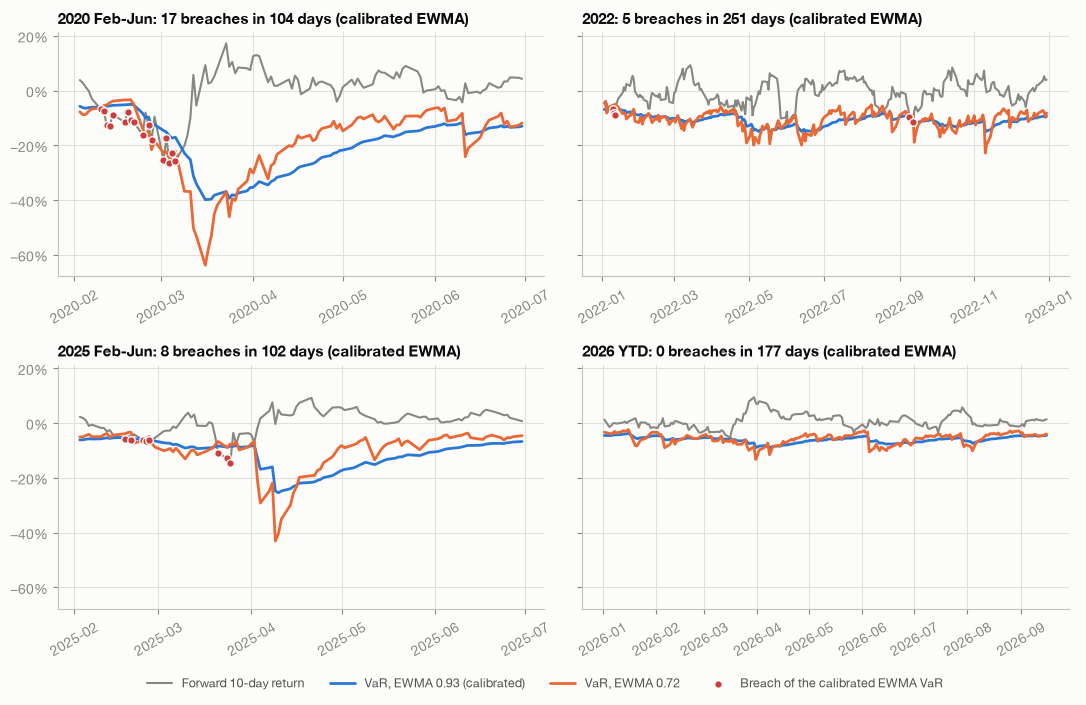

In [5]:
plots.plot_backtest_windows(backtest_data, breach_data, calibrated_lambda);

In February to June 2020, about one breach would be expected in 104 days. The four models had between 13 and 17, and every one of them is in the red zone. All of the breaches fall on VaR dates between 10 February and 6 March. A VaR set on a quiet day in mid-February was compared with the return over the following ten days, and for nearly four weeks each ten-day return was worse than the one before it. A model that only looks backward cannot anticipate that. The fast EWMA recovers soonest, which is why it has 13 breaches against 17 for the others, and by mid-March all four are reserving more than the market then goes on to lose.

Calendar 2022 is the one window in which the models separate. The calibrated EWMA has 5 breaches in 251 days (green) and the rolling 21-day model has 6 (yellow), whereas the fast EWMA has 12 and GARCH has 13 (both red). The ranking from 2020 is reversed. In a market that sold off in bursts separated by quieter weeks, a two-day half-life had forgotten each burst before the next one arrived. GARCH was hurt by a different mechanism. Its 10-day forecast assumes volatility will revert toward its long-run level, so in a year when volatility stayed elevated it reserved the least of the four (9.9% on average against 10.7% to 11.0%).

February to June 2025 produced between 8 and 10 breaches in 102 days, with all four models in the red zone. As in 2020 the breaches come at the start, on VaR dates between 18 February and early April.

In 2026 to date there are no breaches for any model in 177 days. The Kupiec p-value of 0.059 reflects that zero is somewhat fewer than the 1.8 that would be expected, though not by enough to reject at 5%.

Over the full period of 3,195 days, 32 breaches would be expected. The models had 75 (GARCH), 81 (calibrated EWMA), 96 (rolling 21-day) and 111 (fast EWMA), which is a breach rate of between 2.3% and 3.5% against a target of 1%. All four are in the red zone and the Kupiec test rejects correct coverage for each.

The Christoffersen test rejects independence in every window that has breaches. With overlapping 10-day windows this is close to guaranteed, since consecutive forward returns share nine of their ten days and a breach on one day is very likely to be followed by a breach on the next. The result says as much about the overlap as about the models, which is the reason for the robustness check in 4.6.

## 4.5 Capital cost

Mean reserved VaR against breach count: what each model asked to be set aside, and how often that turned out to be too little.

In [6]:
capital_cost = grades[["mean_var", "breaches"]].assign(mean_var=lambda t: (-t["mean_var"] * 100).round(2))
capital_cost.rename(columns={"mean_var": "mean_reserved_var_pct"}).unstack("window")[[("mean_reserved_var_pct", w) for w in ["2020 Feb-Jun", "2022", "2025 Feb-Jun", "Full period"]]
                                                                                    + [("breaches", w) for w in ["2020 Feb-Jun", "2022", "2025 Feb-Jun", "Full period"]]]

mean_reserved_var_pct                                     breaches                              
window                          2020 Feb-Jun   2022 2025 Feb-Jun Full period 2020 Feb-Jun 2022 2025 Feb-Jun Full period
model                                                                                                                  
Rolling 21d                            18.92  11.00        10.80        6.71           17    6           10          96
EWMA 0.72                              18.37  10.73         9.93        6.42           13   12           10         111
EWMA 0.93 (calibrated)                 19.73  10.96        11.23        6.84           17    5            8          81
GARCH(1,1)                             14.84   9.91         9.80        6.73           17   13            8          75

Over the full period the four models reserve similar amounts, between 6.4% and 6.8% of portfolio value on average, and differ much more in how often they are breached. The fast EWMA reserves the least (6.4%) and is breached the most (111 times). GARCH and the calibrated EWMA reserve 6.7% and 6.8% and are breached 75 and 81 times. The rolling 21-day model reserves the same 6.7% as GARCH and is breached 96 times, so on this evidence it is dominated: it costs the same capital and protects less.

The comparison between the fast EWMA and the other models is a real trade-off and not a ranking. It saves about 0.3 to 0.4 points of reserved capital on average in exchange for 30 to 36 more breaches over twelve years.

## 4.6 Robustness: non-overlapping windows

The same backtest restricted to every tenth day, so that no two forward returns share a day. There are ten ways to choose every tenth day, and each is a valid sample, so the table reports the range across all ten together with the number of the ten in which the Kupiec test does not reject.

In [7]:
tables["s4_non_overlapping"].loc[["Full period", "2022"]].round(3)

observations  mean_breaches  min_breaches  max_breaches  breach_pct  offsets_passing_kupiec
window      model                                                                                                              
Full period Rolling 21d                    319.5            9.6             6            12       0.030                       2
            EWMA 0.72                      319.5           11.1             6            16       0.035                       1
            EWMA 0.93 (calibrated)         319.5            8.1             5            11       0.025                       3
            GARCH(1,1)                     319.5            7.5             4            12       0.023                       5
2022        Rolling 21d                     25.1            0.6             0             2       0.024                       8
            EWMA 0.72                       25.1            1.2             0             3       0.048                       7
            EWMA 0.93 (calibrated)          25.1            0.5             0             1       0.020                      10
            GARCH(1,1)                      25.1            1.3             0             3       0.052                       7

On the full period each non-overlapping sample has about 320 independent observations, so 3.2 breaches would be expected. The models produce between 4 and 16 depending on the model and the starting day. The Kupiec test fails to reject in 5 of the 10 samples for GARCH, 3 for the calibrated EWMA, 2 for the rolling model and 1 for the fast EWMA.

The under-coverage is therefore not produced by the overlap. It comes from the two assumptions inside the VaR formula. One is normality: the 10-day returns in this sample have a skewness of −1.5 and an excess kurtosis of 9.3, so the left tail is a good deal heavier than the normal quantile allows for. The other is $\sqrt{10}$ scaling, which carries a volatility measured before a stress period forward across ten days in which volatility is rising.

## 4.7 Current VaR by estimator half-life

,half_life_days,annualized_volatility,var_99_10d
estimator,,,
EWMA 0.72,2.1,8.0,-3.72
EWMA 0.93 (calibrated),9.6,10.1,-4.70
Rolling 21d,10.5,10.8,-5.00
EWMA 0.94,11.2,10.3,-4.77
"GARCH(1,1)",16.8,11.7,-5.43
Rolling 252d,126.0,13.0,-6.01
Full sample since 2013,1728.0,16.8,-7.77


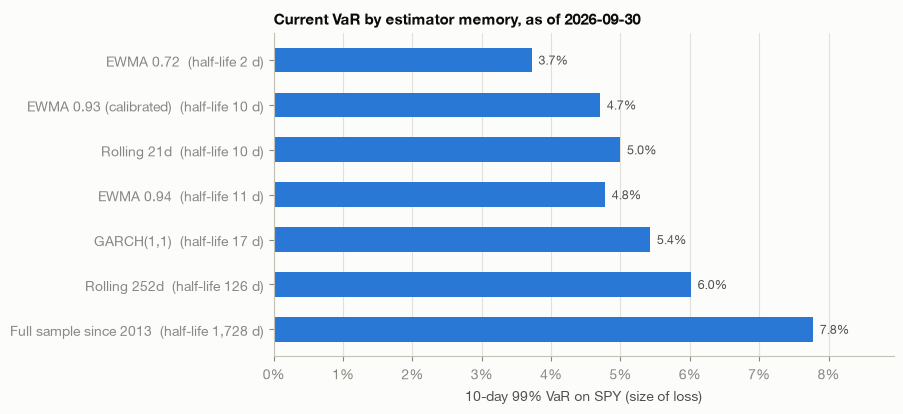

In [8]:
current_var = tables["s4_current_var_by_half_life"]
display(current_var.assign(annualized_volatility=lambda t: (t["annualized_volatility"] * 100).round(1), var_99_10d=lambda t: (t["var_99_10d"] * 100).round(2), half_life_days=lambda t: t["half_life_days"].round(1)))
plots.plot_var_by_half_life(current_var);

Ordered from the shortest memory to the longest, the current 10-day 99% VaR on SPY rises almost monotonically: 3.7% for the fast EWMA, 4.7% to 5.0% for the three estimators with a half-life of about 10 days, 5.4% for GARCH, 6.0% for the trailing year and 7.8% for the full sample since 2013. The shorter the memory, the lower the number. An estimator with a half-life of two days is currently reporting less than half the risk that the thirteen-year average implies.

This is the same pattern as the index volatility figures in Section 2 (11.6%, 15.6% and 24.1%), measured on a different portfolio with a different set of estimators.

## Conclusions

None of the four models would have passed a standard backtest through the stress periods. Each was in the red zone in February to June 2020 and in February to June 2025, and over the full twelve years each was breached between 2.3 and 3.5 times as often as a 99% VaR should be. The result survives the removal of overlapping windows, so it is a property of the parametric-normal, $\sqrt{10}$-scaled VaR and not of how the test was set up.

The choice of estimator matters at the margin and matters differently in different regimes. A very fast estimator did best in the sudden shock of 2020 and worst in the slow grind of 2022. The calibrated EWMA and GARCH were the best over the full period for about the same average capital, and the rolling 21-day window was dominated. No estimator was best in every window.

The breaches themselves share one feature. In both 2020 and 2025 they fall in the first few weeks of the episode, on VaR figures that were set while the trailing window was still calm. The 2026 window has no breaches for any model, and the current VaR estimates are the lowest for the estimators with the shortest memory. The backtest does not say that a stress period is coming, and nothing in this study forecasts one. What it does say is that a VaR figure produced by a short-memory estimator after a quiet period is the figure that has been least reliable in the past, and that the size of the gap between the short-memory and long-memory estimates (3.7% against 7.8% today) is a reasonable measure of how much of the current figure depends on the calm continuing.